In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

In [8]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [9]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")

In [10]:
df["experience_years"] = df["experience_years"].astype("int16")
df["skills_count"] = df["skills_count"].astype("int16")
df["certifications"] = df["certifications"].astype("int8")
df["salary"] = df["salary"].astype("int32")

In [11]:
df.memory_usage(deep=True).sum() / 1024**2

np.float64(3.580202102661133)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   job_title         250000 non-null  category
 1   experience_years  250000 non-null  int16   
 2   education_level   250000 non-null  category
 3   skills_count      250000 non-null  int16   
 4   industry          250000 non-null  category
 5   company_size      250000 non-null  category
 6   location          250000 non-null  category
 7   remote_work       250000 non-null  category
 8   certifications    250000 non-null  int8    
 9   salary            250000 non-null  int32   
dtypes: category(6), int16(2), int32(1), int8(1)
memory usage: 3.6 MB


In [14]:
df.groupby("job_title", observed=True)["salary"].mean().sort_values(ascending=False).head(10)

job_title
AI Engineer                  173498.480640
Machine Learning Engineer    163022.504570
Product Manager              157594.932029
Cloud Engineer               152102.535290
DevOps Engineer              149959.266791
Cybersecurity Analyst        148697.695548
Data Scientist               147258.214409
Software Engineer            141739.521460
Backend Developer            139202.768663
Frontend Developer           132653.842485
Name: salary, dtype: float64

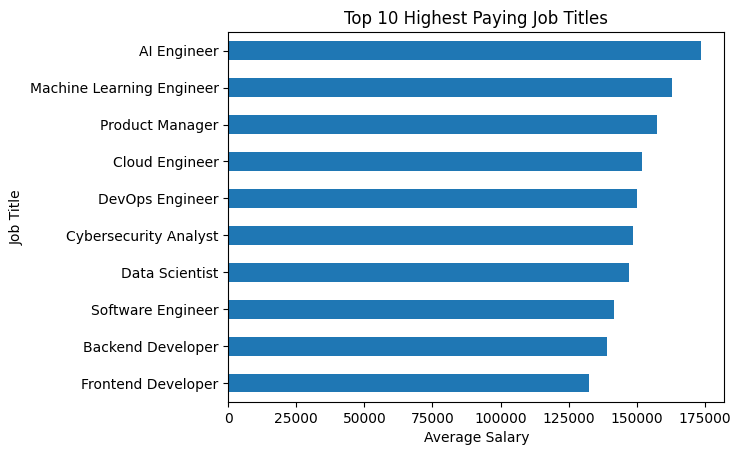

In [17]:
import matplotlib.pyplot as plt

top_jobs = df.groupby("job_title", observed=True)["salary"].mean().sort_values(ascending=False).head(10)

top_jobs.sort_values().plot(kind="barh")
plt.title("Top 10 Highest Paying Job Titles")
plt.xlabel("Average Salary")
plt.ylabel("Job Title")
plt.show()

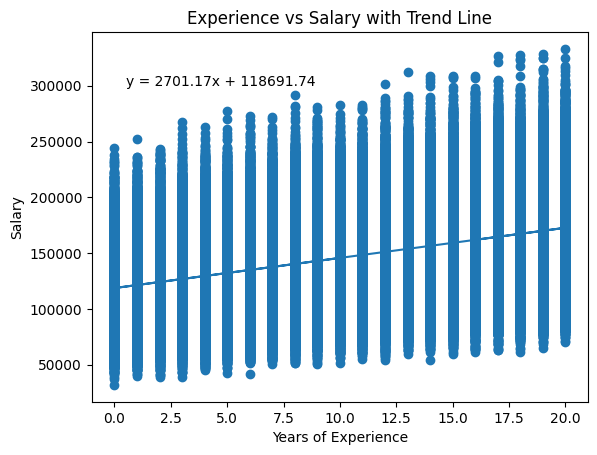

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x = df["experience_years"]
y = df["salary"]

plt.scatter(x, y)

# Calculate line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# Add equation text
plt.text(0.5, max(y)*0.9, f"y = {m:.2f}x + {b:.2f}", fontsize=10)

plt.title("Experience vs Salary with Trend Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [44]:
import numpy as np

def correlation_ratio(categories, values):
    categories = np.array(categories)
    values = np.array(values)
    
    grand_mean = np.mean(values)
    
    unique_categories = np.unique(categories)
    
    numerator = 0
    denominator = np.sum((values - grand_mean)**2)
    
    for category in unique_categories:
        category_values = values[categories == category]
        numerator += len(category_values) * (np.mean(category_values) - grand_mean)**2
    
    return numerator / denominator

# Run it
job_title_corr = correlation_ratio(df["job_title"], df["salary"])
print("Correlation (job_title vs salary):", job_title_corr)

Correlation (job_title vs salary): 0.16126874625587748


## Job Title vs Salary Relationship

Since job_title is a categorical variable, the correlation ratio (η²) was used to measure its relationship with salary.

The result shows that job title explains approximately 16% of salary variation, indicating a weak to moderate relationship.

This suggests that while job role contributes to salary differences, it is not the sole determinant. Salary is influenced by a combination of factors, including experience, education, and other contextual variables.

Furthermore, the high model performance (R² = 0.96) when job title is included indicates that job role becomes more informative when combined with other features, highlighting the importance of feature interactions in predictive modeling.

In [21]:
df["experience_years"].corr(df["salary"])

np.float64(0.4376271392904731)

In [22]:
df["skills_count"].corr(df["salary"])

np.float64(0.12729970793138637)

In [23]:
df["certifications"].corr(df["salary"])

np.float64(0.07381898328393392)

## Correlation Analysis Insight

The analysis shows that salary is driven more by **practical experience** than by the number of skills or certifications.

- Experience has a **moderate positive correlation** with salary.
- Skills count shows a **weak relationship**.
- Certifications have a **very weak relationship**.

### Key Insight
Employers appear to prioritize **real-world experience and practical application** over the number of skills or certifications alone when determining salary.

In [39]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline

# Define features and target
X = df.drop("salary", axis=1)   # includes job_title
y = df["salary"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build the model pipeline
model = make_pipeline(
    OneHotEncoder(handle_unknown="ignore"),
    LinearRegression()
)

# Train the model
model.fit(X_train, y_train)

# Evaluate the model
score = model.score(X_test, y_test)
print("Model R² Score:", score)

Model R² Score: 0.9634594067430522


In [40]:
# Access model components
encoder = model.named_steps["onehotencoder"]
linear_model = model.named_steps["linearregression"]

# Get feature names after encoding
feature_names = encoder.get_feature_names_out(X.columns)

# Get coefficients and intercept
coefficients = linear_model.coef_
intercept = linear_model.intercept_

# Create DataFrame for readability
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Show top features
coef_df.sort_values(by="Coefficient", ascending=False).head(15)

,Feature,Coefficient
81,location_USA,35673.151765
0,job_title_AI Engineer,28027.948515
32,experience_years_20,27006.230459
31,experience_years_19,24339.865402
67,company_size_Enterprise,24042.983815
73,location_Canada,21644.329723
30,experience_years_18,21539.397498
29,experience_years_17,18806.582126
37,education_level_PhD,18276.618593
9,job_title_Machine Learning Engineer,17367.535741


In [41]:
# Access trained model components
encoder = model.named_steps["onehotencoder"]
linear_model = model.named_steps["linearregression"]

# Get feature names after encoding
feature_names = encoder.get_feature_names_out(X.columns)

# Get coefficients and intercept
coefficients = linear_model.coef_
intercept = linear_model.intercept_

# Build equation string
equation = f"Salary = {intercept:.2f}"

for feature, coef in zip(feature_names, coefficients):
    if coef >= 0:
        equation += f" + ({coef:.2f} * {feature})"
    else:
        equation += f" - ({abs(coef):.2f} * {feature})"

# Print equation
print(equation)

Salary = 145662.28 + (28027.95 * job_title_AI Engineer) - (6293.21 * job_title_Backend Developer) - (23515.33 * job_title_Business Analyst) + (6548.34 * job_title_Cloud Engineer) + (3341.78 * job_title_Cybersecurity Analyst) - (25731.29 * job_title_Data Analyst) + (1126.27 * job_title_Data Scientist) + (4349.38 * job_title_DevOps Engineer) - (12860.26 * job_title_Frontend Developer) + (17367.54 * job_title_Machine Learning Engineer) + (11902.39 * job_title_Product Manager) - (4263.54 * job_title_Software Engineer) - (27121.55 * experience_years_0) - (24245.78 * experience_years_1) - (21525.82 * experience_years_2) - (18879.22 * experience_years_3) - (16164.91 * experience_years_4) - (13581.06 * experience_years_5) - (10838.29 * experience_years_6) - (7980.29 * experience_years_7) - (5307.54 * experience_years_8) - (2706.26 * experience_years_9) - (24.96 * experience_years_10) + (2718.60 * experience_years_11) + (5447.97 * experience_years_12) + (8015.12 * experience_years_13) + (10843.

## Correlation Analysis Insight

The analysis indicates that salary is more strongly influenced by practical experience than by the number of skills or certifications.

Experience shows a moderate positive correlation with salary (approximately 0.44), suggesting that as experience increases, salary tends to increase as well.

In contrast, skills count exhibits a weak relationship with salary (approximately 0.13), while certifications show a very weak relationship (approximately 0.07). This implies that simply having more skills or certifications does not significantly impact salary without corresponding experience.

Overall, the findings suggest that employers place greater value on real-world experience and practical exposure than on the quantity of skills or certifications alone.

## Model Performance Interpretation

The final model achieved an R² score of 0.96, indicating that approximately 96% of the variation in salary can be explained by the features included in the model.

This high level of accuracy suggests that the selected variables, particularly job title and experience, are strong predictors of salary.

However, such a high R² score may also indicate that certain variables, such as job title, strongly encode salary information, making the model highly predictive but less interpretable.

## Model Comparison Insight

A comparison of different modeling approaches revealed the impact of both feature selection and encoding techniques on model performance.

Using OneHotEncoding with all features, including job title, produced a high-performing model with an R² score of 0.96.

When job title was removed, the model still achieved a strong performance (R² ≈ 0.80), indicating that other variables such as experience, education, and industry also contribute significantly to salary prediction.

However, when OrdinalEncoding was used, model performance dropped substantially (R² ≈ 0.45). This decline occurred because ordinal encoding imposes artificial ordering on categorical variables, which does not reflect real-world relationships.

These results highlight the importance of appropriate encoding techniques and demonstrate that job title enhances predictive accuracy but is not the sole determinant of salary.

## Final Insight

The analysis demonstrates that salary is influenced by a combination of factors rather than a single dominant variable.

Job title plays a significant role in improving predictive performance, indicating that salary structures are largely role-dependent. However, experience remains a key contributing factor, while skills and certifications have comparatively weaker effects.

This suggests that salary determination is multi-dimensional, with job role providing a baseline and other factors such as experience and contextual attributes refining the final outcome.

## Model Equation Interpretation

The salary prediction model can be expressed as a linear combination of multiple factors:

Salary = Intercept + Experience + Skills + Certifications + Job Title Effects + Education Effects + Contextual Factors

Where:
- The intercept represents the baseline salary.
- Experience contributes positively to salary growth.
- Skills and certifications have smaller marginal effects.
- Job title contributes significantly through categorical effects.
- Education, industry, and location provide additional contextual adjustments.

This formulation reflects how different factors collectively influence salary rather than acting independently.